# The low-level coupling API

`FDSolver` can solve coupled multi-field equations, and comes with high-level helpers for common cases: `add_TETM` for TE/TM polarization splitting, and `add_on_site_coupling` for a simple uniform coupling between two fields (see [PillarsTETM.ipynb](PillarsTETM.ipynb) for a worked TE/TM example). Both are themselves built out of three lower-level primitives: `add_coupling_parameter`, `add_coupling_matrix` and `add_coupling`. This tutorial walks through those primitives directly, so you can build your own custom coupling terms.

As a minimal, checkable example, we consider two fields trapped in otherwise identical circular pillars, with a constant energy offset (a *detuning*) between them. Without any coupling, their ground-state energies simply cross as a function of the detuning. Turning on a coupling term opens a gap at the crossing point - the classic avoided-crossing (level-repulsion) picture, whose minimum gap we can predict and check against the solver's output.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sps
from bloch_schrodinger.potential import Potential, create_parameter
from bloch_schrodinger.fdsolver import FDSolver
from bloch_schrodinger.plotting import plot_cuts

a1 = [2.1,0]
a2 = [0,2.1]

# Field 0: a bare circular pillar
pillar0 = Potential(
    unitvecs=[a1,a2],
    resolution = (75,74), # slight anisotropy to prevent exact degeneracies, which numerical solvers don't like
    v0 = 600
)
pillar0.circle(center=(0,0), radius = 1)

# Field 1: the exact same pillar, offset everywhere by a swept detuning.
# Adding a constant to a potential shifts every eigenvalue of that field by the same amount,
# so this lets us build two branches that cross exactly at detuning = 0.
detuning = create_parameter('detuning', np.linspace(-1.5, 1.5, 31))
pillar1 = pillar0.copy()
pillar1.add(detuning)

solv = FDSolver(
    potentials = [pillar0, pillar1], # Unlike PillarsTETM, the two fields see genuinely different potentials here
    alphas = [1, 1]
)

Let's first check that the two branches actually cross, before adding any coupling. With no coupling terms registered, the Hamiltonian is exactly block-diagonal in field space, so `solve` simply returns the two lowest eigenvalues of the combined (uncoupled) system.

Diagonalizing:   0%|          | 0/31 [00:00<?, ?matrix/s]

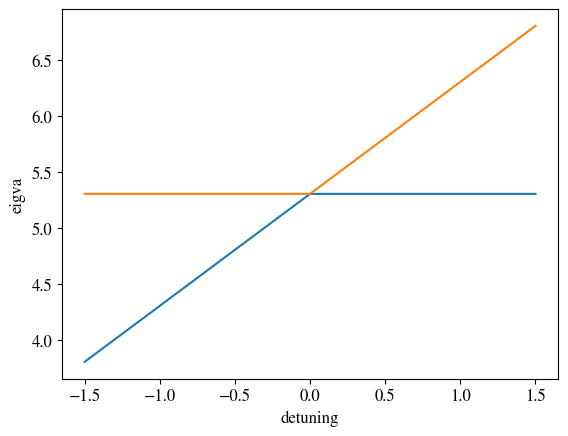

In [2]:
eigva0, eigve0 = solv.solve(n_eigva=2, parallel=True)

plot_cuts(eigva0, 'detuning')
plt.show()

## `add_coupling_parameter` and `add_coupling_matrix`

`add_coupling_parameter(name, parameter)` registers a scalar or swept value that can be referred to by name in a coupling expression, exactly like `alpha`/`beta`/`gamma` are registered in `PillarsTETM.ipynb`. Here, we sweep a coupling strength `Omega`.

`add_coupling_matrix(name, struct, field1, field2)` registers the *spatial structure* of a coupling term: a `(n_points, n_points)` sparse matrix acting on the flattened potential grid. You only ever supply the `field1 -> field2` block (`struct`); the `field2 -> field1` block is filled in automatically as its conjugate transpose, so the assembled coupling is Hermitian by construction. Here, instead of the identity matrix used implicitly by `add_on_site_coupling`, we use a Gaussian bump localized on the pillar, to show a coupling with real spatial structure.

In [3]:
Omega = create_parameter('Omega', np.array([0.02, 0.05, 0.1]))
solv.add_coupling_parameter('Omega', Omega)

# A real, spatially localized coupling structure centered on the pillar
bump = np.exp(-(pillar0.x**2 + pillar0.y**2) / (2 * 0.6**2))

# Flatten it exactly the way FDSolver flattens potentials internally, so indices line up
bump_flat = bump.stack(idiag=['a1', 'a2']).data
bump_matrix = sps.diags(bump_flat)

solv.add_coupling_matrix('bump', bump_matrix, field1=0, field2=1)

## `add_coupling` and a Hermiticity pitfall

`add_coupling(expr)` registers a string expression, evaluated at Hamiltonian-build time against every registered parameter and matrix (plus the current point in parameter space). We can now combine `Omega` and `bump` into an actual coupling term:

```python
solv.add_coupling('Omega * bump')
```

One thing to be careful of: `bump` (as stored by `add_coupling_matrix`) is already the full, Hermitian, two-field block matrix. Multiplying it by a *real* scalar like `Omega` keeps it Hermitian. But multiplying it by something imaginary, e.g. writing `'1j * Omega * bump'`, would **break** Hermiticity, because the `field2 -> field1` block was already fixed as the conjugate transpose of the *original* real `bump`, not of `1j * bump`. We can check this directly on the assembled matrix, without running the solver:

In [4]:
solv.add_coupling('Omega * bump')

# Checking Hermiticity directly on the assembled block matrix, without densifying it
correct = solv.coupling_context['bump']
broken = 1j * correct

print("max asymmetry, correct coupling:", abs(correct - correct.conj().T).max())
print("max asymmetry, broken coupling: ", abs(broken - broken.conj().T).max())

max asymmetry, correct coupling: 0.0
max asymmetry, broken coupling:  1.9994408196023457


Now that we've confirmed the assembled coupling matrix is genuinely Hermitian, let's solve the coupled problem and see the avoided crossing appear:

Diagonalizing:   0%|          | 0/93 [00:00<?, ?matrix/s]

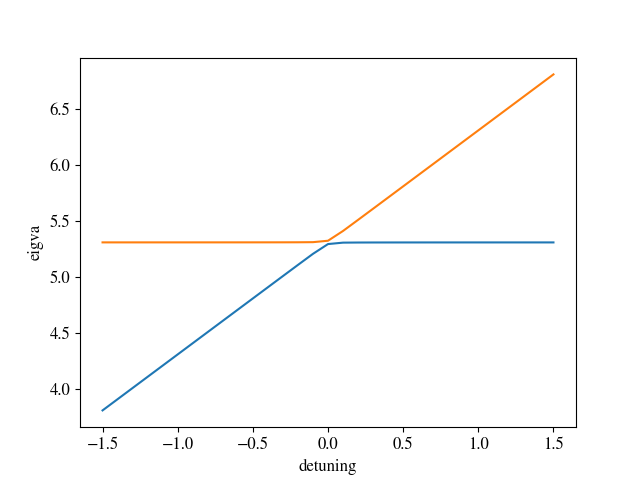

In [8]:
eigva, eigve = solv.solve(n_eigva=2, parallel=True)

%matplotlib widget
plot_cuts(eigva, 'detuning')
plt.show()

Sweeping the `Omega` slider should show the gap at `detuning = 0` growing with the coupling strength. Since both fields share the same spatial profile at the crossing point, the size of that gap is controlled by the overlap of the ground state with our `bump` profile, weighted by `Omega`.

## `add_on_site_coupling`: the same primitives, packaged

For a coupling with no spatial structure - just a uniform strength between the two fields everywhere - `add_on_site_coupling(expr, field1, field2)` is a convenient shortcut. It does exactly what we just did by hand: it builds a real identity matrix and a purely-imaginary identity matrix via two `add_coupling_matrix` calls, then combines them via `add_coupling`, using the same real/imaginary-Hermitian-matrix trick from the previous section, generalized to a complex coupling strength.

For a uniform coupling (unlike our localized `bump`), the minimum gap at `detuning = 0` has a clean closed form: $2\,\Omega$, since the on-site matrix element between two identical, unit-normalized ground states is just $\Omega \langle \psi_0 | \psi_0 \rangle = \Omega$.

Diagonalizing:   0%|          | 0/31 [00:00<?, ?matrix/s]

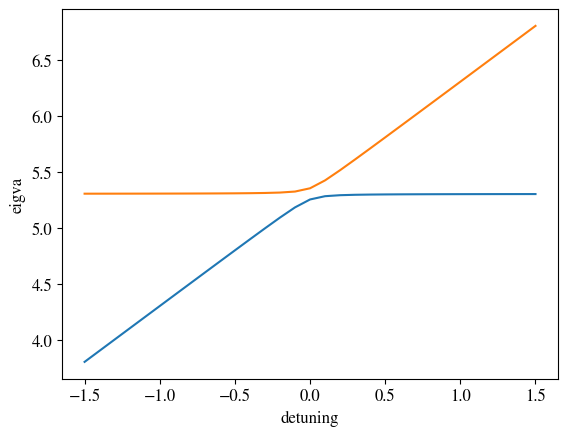

minimum gap: 0.1000 (expected 2*Omega = 0.1)


In [6]:
solv_uniform = FDSolver(
    potentials = [pillar0, pillar1],
    alphas = [1, 1]
)

Omega_u = create_parameter('Omega', np.array([0.05]))
solv_uniform.add_coupling_parameter('Omega', Omega_u)
solv_uniform.add_on_site_coupling(expr='Omega', field1=0, field2=1)

eigva_u, eigve_u = solv_uniform.solve(n_eigva=2, parallel=True)

plot_cuts(eigva_u, 'detuning')
plt.show()

gap = eigva_u.sel(band=1) - eigva_u.sel(band=0)
print(f"minimum gap: {float(gap.min()):.4f} (expected 2*Omega = {2*0.05})")